In [31]:
"""
IRL (Inverse Reinforcement Learning) Trainer for Variable Admittance Control
Peg-in-Hole Task Implementation

This notebook implements a Max-Ent IRL pipeline:
1) Learn a reward function r_\theta(s, a) that assigns higher reward to expert data than to policy rollouts.
2) Optimize a policy with on-policy PPO using the learned reward r_\theta.


Variable Admittance Control:
- State Space (12D): [pos_err(3), pos_des(3), rot_err(3), rot_des(3)]
- Action Space (7D): [K1..K6, damping_ratio]
- Damping matrix: B = damping_ratio * sqrt(K)
"""

import os
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Normal
import pickle
import matplotlib.pyplot as plt
from collections import deque
import random
from typing import Dict, List, Tuple, Optional
import logging

current_dir = os.getcwd()

if 'mujoco_wrappers' in current_dir:
    if not current_dir.endswith('mujoco_wrappers'):
        # Navigate to root
        root_path = current_dir.split('mujoco_wrappers')[0] + 'mujoco_wrappers'
        os.chdir(root_path)
        print(f"Changed working directory to: {os.getcwd()}")
else:
    print("Warning: Could not find mujoco_wrappers in current path")

# Add path for environment
sys.path.append(os.getcwd())

from envs.peg_in_hole_env import PegInHoleEnv

# Set up logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Working directory: {os.getcwd()}")


Using device: cuda
Working directory: /home/auksphere/robotics/mujoco_wrappers


In [32]:
# --- MaxEnt IRL components ---
# MaxEnt IRL + SAC implementation.
#
#   - Reward: r_θ(s,a)=θᵀf(s,a) (f choosen according to specific mission)
#   - Policy improvement: maximize E[r_θ(s,a) + α H(π(.|s))] via SAC
#   - Reward update: moment matching (expert feature expectations vs policy feature expectations)
#
# Stability notes:
#   - Moment matching can cause θ to grow without bound if feature expectations don't match well early on.
#   - Unbounded θ -> rewards explode -> Q targets explode -> q_loss explodes.
#   - We address this by (a) shrinking θ (weight decay / L2), (b) clipping θ-norm, (c) clipping reward.

import math

def _to_tensor(x, device, dtype=torch.float32):
    return torch.as_tensor(x, dtype=dtype, device=device)


class MaxEntLinearReward(nn.Module):
    """Linear reward r_theta(s,a) = theta^T phi(s,a)."""

    def __init__(self, feature_dim: int, reward_clip: float = 20.0):
        super().__init__()
        self.theta = nn.Parameter(torch.zeros(feature_dim))
        self.reward_clip = float(reward_clip)

    def forward(self, phi: torch.Tensor) -> torch.Tensor:
        # phi: (B, feature_dim) -> (B,)
        r = (phi * self.theta.unsqueeze(0)).sum(dim=-1)
        if self.reward_clip is not None and self.reward_clip > 0:
            r = torch.clamp(r, -self.reward_clip, self.reward_clip)
        return r


def _near_hole_progress(state_norm: torch.Tensor, eps: float = 1e-6) -> torch.Tensor:
    """
    Compute a smooth 'near-hole progress' rho in [0,1] from normalized state.
    Proxy with position error magnitude: rho = exp(-||e_pos|| / sigma).
    """
    pos_err = state_norm[..., 0:3]
    dist = torch.linalg.norm(pos_err, dim=-1, keepdim=True)  # (B,1)
    sigma = 0.75
    rho = torch.exp(-dist / (sigma + eps))
    return torch.clamp(rho, 0.0, 1.0)


def phi_sa(state: torch.Tensor, action: torch.Tensor) -> torch.Tensor:
    """
    Improved feature map φ(s,a) for gain-scheduling in peg-in-hole.
    Assumes state/action already normalized to [-1,1].
    """
    rho = _near_hole_progress(state)  # (B,1)

    # group actions: action = [K1..K6, d] in normalized space
    K = action[..., 0:6]
    d = action[..., 6:7]
    K_xy = K[..., 0:2].abs().mean(dim=-1, keepdim=True)       # (B,1)
    K_z  = K[..., 2:3].abs()                                  # (B,1)
    K_rot = K[..., 3:6].abs().mean(dim=-1, keepdim=True)      # (B,1)
    d_abs = d.abs()                                           # (B,1)

    pos_err = state[..., 0:3]
    rot_err = state[..., 6:9]
    pos_err_norm = torch.linalg.norm(pos_err, dim=-1, keepdim=True)  # (B,1)
    rot_err_norm = torch.linalg.norm(rot_err, dim=-1, keepdim=True)  # (B,1)

    feat = torch.cat(
        [
            state,
            action,
            rho,
            rho * action,
            K_xy, K_z, K_rot, d_abs,
            pos_err_norm, rot_err_norm,
        ],
        dim=-1,
    )
    return feat


class SoftQNetwork(nn.Module):
    """Q(s,a) network for SAC."""

    def __init__(self, state_dim=12, action_dim=7, hidden_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim + action_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, state: torch.Tensor, action: torch.Tensor) -> torch.Tensor:
        x = torch.cat([state, action], dim=-1)
        return self.net(x).squeeze(-1)


class GaussianPolicy(nn.Module):
    """Tanh-squashed Gaussian policy for continuous actions in [-1,1]."""

    def __init__(self, state_dim=12, action_dim=7, hidden_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        self.mean = nn.Linear(hidden_dim, action_dim)
        self.log_std = nn.Linear(hidden_dim, action_dim)

        self.LOG_STD_MIN = -5.0
        self.LOG_STD_MAX = 2.0

    def forward(self, state: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        h = self.net(state)
        mean = self.mean(h)
        log_std = self.log_std(h)
        log_std = torch.clamp(log_std, self.LOG_STD_MIN, self.LOG_STD_MAX)
        return mean, log_std

    def sample(self, state: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """Returns: action in [-1,1], log_prob(a|s)."""
        mean, log_std = self.forward(state)
        std = torch.exp(log_std)
        dist = Normal(mean, std)
        z = dist.rsample()
        action = torch.tanh(z)

        # Log prob with tanh correction
        log_prob = dist.log_prob(z).sum(dim=-1)
        log_prob -= torch.log(1.0 - action.pow(2) + 1e-6).sum(dim=-1)
        return action, log_prob

    def deterministic(self, state: torch.Tensor) -> torch.Tensor:
        mean, _ = self.forward(state)
        return torch.tanh(mean)


class SACAgent:
    """Minimal SAC agent for normalized (s,a) in [-1,1]."""

    def __init__(
        self,
        state_dim=12,
        action_dim=7,
        hidden_dim=256,
        lr=3e-4,
        gamma=0.99,
        tau=0.005,
        alpha=0.2,
        autotune_alpha=True,
        target_entropy: Optional[float] = None,
        device: Optional[torch.device] = None,
        grad_clip_norm: float = 10.0,
    ):
        self.device = device if device is not None else torch.device("cpu")
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.gamma = float(gamma)
        self.tau = float(tau)
        self.grad_clip_norm = float(grad_clip_norm)

        self.q1 = SoftQNetwork(state_dim, action_dim, hidden_dim).to(self.device)
        self.q2 = SoftQNetwork(state_dim, action_dim, hidden_dim).to(self.device)
        self.q1_target = SoftQNetwork(state_dim, action_dim, hidden_dim).to(self.device)
        self.q2_target = SoftQNetwork(state_dim, action_dim, hidden_dim).to(self.device)
        self.q1_target.load_state_dict(self.q1.state_dict())
        self.q2_target.load_state_dict(self.q2.state_dict())

        self.actor = GaussianPolicy(state_dim, action_dim, hidden_dim).to(self.device)

        self.q_optimizer = optim.Adam(list(self.q1.parameters()) + list(self.q2.parameters()), lr=lr)
        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=lr)

        self.autotune_alpha = bool(autotune_alpha)
        if target_entropy is None:
            target_entropy = -float(action_dim)
        self.target_entropy = float(target_entropy)

        if self.autotune_alpha:
            self.log_alpha = torch.tensor(math.log(alpha), device=self.device, requires_grad=True)
            self.alpha_optimizer = optim.Adam([self.log_alpha], lr=lr)
            self.alpha = float(alpha)
        else:
            self.log_alpha = None
            self.alpha_optimizer = None
            self.alpha = float(alpha)

    @torch.no_grad()
    def act(self, state: np.ndarray, deterministic: bool = False) -> np.ndarray:
        s = _to_tensor(state, self.device).unsqueeze(0)
        if deterministic:
            a = self.actor.deterministic(s)
        else:
            a, _ = self.actor.sample(s)
        return a.squeeze(0).cpu().numpy()

    def update(self, batch: Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]) -> Dict[str, float]:
        """One SAC update step."""
        states, actions, rewards, next_states, dones = batch
        s = _to_tensor(states, self.device)
        a = _to_tensor(actions, self.device)
        r = _to_tensor(rewards, self.device).squeeze(-1)
        s2 = _to_tensor(next_states, self.device)
        d = _to_tensor(dones, self.device).squeeze(-1)

        # --- Critic update ---
        with torch.no_grad():
            a2, logp_a2 = self.actor.sample(s2)
            q1_t = self.q1_target(s2, a2)
            q2_t = self.q2_target(s2, a2)
            q_t = torch.min(q1_t, q2_t)
            alpha = self.alpha if not self.autotune_alpha else self.log_alpha.exp().item()
            target_v = q_t - alpha * logp_a2
            target_q = r + self.gamma * (1.0 - d) * target_v
            # prevent rare blow-ups from killing training
            target_q = torch.clamp(target_q, -100.0, 100.0)

        q1 = self.q1(s, a)
        q2 = self.q2(s, a)
        q_loss = F.mse_loss(q1, target_q) + F.mse_loss(q2, target_q)

        self.q_optimizer.zero_grad(set_to_none=True)
        q_loss.backward()
        if self.grad_clip_norm is not None and self.grad_clip_norm > 0:
            torch.nn.utils.clip_grad_norm_(list(self.q1.parameters()) + list(self.q2.parameters()), self.grad_clip_norm)
        self.q_optimizer.step()

        # --- Actor update ---
        a_pi, logp_pi = self.actor.sample(s)
        q1_pi = self.q1(s, a_pi)
        q2_pi = self.q2(s, a_pi)
        q_pi = torch.min(q1_pi, q2_pi)

        alpha_t = self.alpha if not self.autotune_alpha else self.log_alpha.exp()
        actor_loss = (alpha_t * logp_pi - q_pi).mean()

        self.actor_optimizer.zero_grad(set_to_none=True)
        actor_loss.backward()
        if self.grad_clip_norm is not None and self.grad_clip_norm > 0:
            torch.nn.utils.clip_grad_norm_(self.actor.parameters(), self.grad_clip_norm)
        self.actor_optimizer.step()

        # --- Alpha update ---
        alpha_loss = torch.tensor(0.0, device=self.device)
        if self.autotune_alpha:
            alpha_loss = -(self.log_alpha * (logp_pi.detach() + self.target_entropy)).mean()
            self.alpha_optimizer.zero_grad(set_to_none=True)
            alpha_loss.backward()
            self.alpha_optimizer.step()

        # --- Target update ---
        with torch.no_grad():
            for p, pt in zip(self.q1.parameters(), self.q1_target.parameters()):
                pt.data.mul_(1 - self.tau).add_(self.tau * p.data)
            for p, pt in zip(self.q2.parameters(), self.q2_target.parameters()):
                pt.data.mul_(1 - self.tau).add_(self.tau * p.data)

        out = {
            "q_loss": float(q_loss.item()),
            "actor_loss": float(actor_loss.item()),
            "alpha_loss": float(alpha_loss.item()),
        }
        if self.autotune_alpha:
            out["alpha"] = float(self.log_alpha.exp().item())
        else:
            out["alpha"] = float(self.alpha)
        return out


def maxent_reward_moment_matching_update(
    reward_model: MaxEntLinearReward,
    expert_states: torch.Tensor,
    expert_actions: torch.Tensor,
    policy_states: torch.Tensor,
    policy_actions: torch.Tensor,
    lr_theta: float = 1e-2,
    theta_l2: float = 1e-4,
    theta_clip_norm: float = 10.0,
    grad_clip_norm: float = 1.0,
    ) -> Dict[str, float]:
    """
    Moment-matching step with stabilization.
    θ ← (1-λ)θ + lr * clip(E[φ]_E - E[φ]_π)
    """
    with torch.no_grad():
        phi_e = phi_sa(expert_states, expert_actions).mean(dim=0)
        phi_p = phi_sa(policy_states, policy_actions).mean(dim=0)
        grad = (phi_e - phi_p)
        grad_norm = float(grad.norm().item())
        if grad_clip_norm is not None and grad_clip_norm > 0:
            gn = grad.norm() + 1e-8
            scale = min(1.0, float(grad_clip_norm) / float(gn.item()))
            grad = grad * scale
        # L2 shrinkage on theta (prevents drift / reward explosion)
        if theta_l2 is not None and theta_l2 > 0:
            reward_model.theta.mul_(1.0 - float(theta_l2))
        reward_model.theta.add_(lr_theta * grad)
        if theta_clip_norm is not None and theta_clip_norm > 0:
            tn = reward_model.theta.norm() + 1e-8
            if float(tn.item()) > float(theta_clip_norm):
                reward_model.theta.mul_(float(theta_clip_norm) / float(tn.item()))
        theta_norm = float(reward_model.theta.norm().item())
        return {"grad_norm": grad_norm, "theta_norm": theta_norm}

In [33]:
class VariableImpedancePolicy(nn.Module):
    """Policy network for impedance learning"""
    def __init__(self, state_dim=12, action_dim=7, hidden_dim=128):
        super(VariableImpedancePolicy, self).__init__()
        
        self.error_encoder = nn.Sequential(
            nn.Linear(3, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.1)
        )
        
        self.position_encoder = nn.Sequential(
            nn.Linear(3, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.1)
        )

        self.rot_error_encoder = nn.Sequential(
            nn.Linear(3, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.1)
        )

        self.rot_desired_encoder = nn.Sequential(
            nn.Linear(3, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.1)
        )
        
        self.shared_net = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh()
        )
        
        self.stiffness_branch = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.Tanh(),
            nn.Linear(hidden_dim // 2, 12)
        )
        
        self.damping_branch = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim // 2, hidden_dim // 4),
            nn.Tanh(),
            nn.Linear(hidden_dim // 4, 2)
        )
        
        self._initialize_weights()
    
    def _initialize_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight, gain=0.8)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
        
        with torch.no_grad():
            self.stiffness_branch[-1].weight.data *= 0.5
            self.stiffness_branch[-1].bias.data[:6] = 0.3
            self.stiffness_branch[-1].bias.data[6:] = -0.7
            
            self.damping_branch[-1].weight.data *= 0.7
            self.damping_branch[-1].bias.data[0] = 0.2
            self.damping_branch[-1].bias.data[1] = -0.5
    
    def forward(self, state):
        if torch.isnan(state).any():
            state = torch.where(torch.isnan(state), torch.zeros_like(state), state)
        
        tracking_error = state[:, :3]
        desired_position = state[:, 3:6]
        rot_error = state[:, 6:9]
        desired_rot = state[:, 9:12]
        
        error_features = self.error_encoder(tracking_error)
        position_features = self.position_encoder(desired_position)
        rot_error_features = self.rot_error_encoder(rot_error)
        rot_desired_features = self.rot_desired_encoder(desired_rot)
        
        combined_features = torch.cat(
            [error_features, position_features, rot_error_features, rot_desired_features], dim=-1
        )
        shared_features = self.shared_net(combined_features)
        
        stiffness_output = self.stiffness_branch(shared_features)
        damping_output = self.damping_branch(shared_features)
        
        stiffness_mean = stiffness_output[:, :6]
        stiffness_log_std = stiffness_output[:, 6:]
        damping_mean = damping_output[:, 0:1]
        damping_log_std = damping_output[:, 1:2]
        
        mean = torch.cat([stiffness_mean, damping_mean], dim=-1)
        log_std = torch.cat([stiffness_log_std, damping_log_std], dim=-1)
        
        mean = torch.clamp(mean, min=-2.5, max=2.5)
        log_std = torch.clamp(log_std, min=-1.0, max=0.7)
        
        return mean, log_std
    
    def sample_action(self, state):
        """Sample action with tanh squashing to [-1, 1]"""
        mean, log_std = self.forward(state)
        std = torch.exp(log_std)
        std = torch.clamp(std, min=0.1, max=1.5)
        
        try:
            dist = Normal(mean, std)
            z = dist.rsample()
            action = torch.tanh(z)
            
            log_prob = dist.log_prob(z).sum(dim=-1)
            log_prob -= torch.log(1 - action.pow(2) + 1e-8).sum(dim=-1)
            log_prob = torch.clamp(log_prob, min=-12, max=12)
            
            return action, log_prob
        except Exception:
            action = torch.tanh(mean)
            log_prob = torch.zeros(action.shape[0], device=action.device)
            return action, log_prob
    
    def evaluate_action(self, state, action):
        """Evaluate log probability of given action in [-1, 1]"""
        mean, log_std = self.forward(state)
        std = torch.exp(log_std)
        std = torch.clamp(std, min=0.1, max=1.5)
        
        action = torch.clamp(action, min=-0.999, max=0.999)
        z = 0.5 * torch.log((1 + action) / (1 - action + 1e-8))
        
        try:
            dist = Normal(mean, std)
            log_prob = dist.log_prob(z).sum(dim=-1)
            log_prob -= torch.log(1 - action.pow(2) + 1e-8).sum(dim=-1)
            return torch.clamp(log_prob, min=-12, max=12)
        except Exception:
            return torch.zeros(action.shape[0], device=action.device)
    
    def get_deterministic_action(self, state):
        """Deterministic action for evaluation"""
        mean, _ = self.forward(state)
        return torch.tanh(mean)


In [34]:
class ExpertDataLoader:
    """
    Load and process expert demonstration data
    Format: [e_t(3), pd_t(3), action] where:
    - e_t: tracking error (3D position) 
    - pd_t: desired position (3D position)
    - action: [K1, K2, K3, K4, K5, K6, damping_ratio] impedance parameters
    """
    def __init__(self, expert_data_path):
        self.expert_data_path = expert_data_path
        self.trajectories = []
        self.obs_stats = None
        self.act_stats = None
        self.load_expert_data()
    
    def load_expert_data(self):
        """Load expert trajectories from pickle file"""
        try:
            with open(self.expert_data_path, 'rb') as f:
                data = pickle.load(f)
            
            print(f"Loaded expert data from {self.expert_data_path}")
            
            # Expected format from vac_expert_generator.py merge
            if isinstance(data, dict) and 'observations' in data and 'actions' in data:
                observations = np.array(data['observations'])  # Shape: (N, 6) [e_t(3), pd_t(3)]
                actions = np.array(data['actions'])           # Shape: (N, 7) [K1-K6, damping]
                
                print(f"✓ Data format validated")
                print(f"✓ Observations: {observations.shape} - {data['metadata']['observation_description']}")
                print(f"✓ Actions: {actions.shape} - {data['metadata']['action_description']}")
                print(f"✓ Total samples: {len(observations)}")
                print(f"✓ Trajectories: {data['metadata']['num_trajectories']}")
                
                # Calculate statistics for normalization
                self.obs_stats = {
                    'mean': observations.mean(axis=0),
                    'std': observations.std(axis=0),
                    'min': observations.min(axis=0),
                    'max': observations.max(axis=0)
                }
                
                self.act_stats = {
                    'mean': actions.mean(axis=0),
                    'std': actions.std(axis=0),
                    'min': actions.min(axis=0),
                    'max': actions.max(axis=0)
                }
                
                # Split into trajectories based on metadata
                trajectory_indices = data['metadata']['trajectory_indices']
                num_trajectories = data['metadata']['num_trajectories']
                
                # Estimate trajectory length (assuming roughly equal lengths)
                avg_traj_len = len(observations) // num_trajectories
                
                # Create trajectories (simplified - could use actual trajectory boundaries)
                for i in range(num_trajectories):
                    start_idx = i * avg_traj_len
                    end_idx = min((i + 1) * avg_traj_len, len(observations))
                    
                    if start_idx < len(observations):
                        traj_obs = observations[start_idx:end_idx]
                        traj_acts = actions[start_idx:end_idx]
                        
                        # Create next states (shifted by 1)
                        if len(traj_obs) > 1:
                            next_states = traj_obs[1:]
                            traj_obs = traj_obs[:-1] 
                            traj_acts = traj_acts[:-1]
                        else:
                            next_states = traj_obs.copy()
                        
                        trajectory = {
                            'states': traj_obs,
                            'actions': traj_acts,
                            'next_states': next_states
                        }
                        self.trajectories.append(trajectory)
                
                print(f"✓ Created {len(self.trajectories)} trajectory segments")
                
                # Print data ranges for verification
                print(f"\nData Ranges:")
                print(f"  Tracking Error (e_t): X[{observations[:, 0].min():.3f}, {observations[:, 0].max():.3f}] Y[{observations[:, 1].min():.3f}, {observations[:, 1].max():.3f}] Z[{observations[:, 2].min():.3f}, {observations[:, 2].max():.3f}]")
                print(f"  Desired Pos (pd_t):   X[{observations[:, 3].min():.3f}, {observations[:, 3].max():.3f}] Y[{observations[:, 4].min():.3f}, {observations[:, 4].max():.3f}] Z[{observations[:, 5].min():.3f}, {observations[:, 5].max():.3f}]")
                print(f"  Stiffness K1-K3:     [{actions[:, :3].min():.0f}, {actions[:, :3].max():.0f}] N/m")
                print(f"  Stiffness K4-K6:     [{actions[:, 3:6].min():.0f}, {actions[:, 3:6].max():.0f}] Nm/rad")
                print(f"  Damping ratio:       [{actions[:, 6].min():.2f}, {actions[:, 6].max():.2f}]")
                
                # Analyze damping coefficient distribution
                damping_data = actions[:, 6]
                print(f"\nDamping coefficient analysis:")
                print(f"  Mean: {damping_data.mean():.3f}")
                print(f"  Std dev: {damping_data.std():.3f}")
                print(f"  Coefficient of variation: {damping_data.std()/damping_data.mean():.3f}")
                
            else:
                print(f"✗ Unexpected data format: {type(data)}")
                if hasattr(data, 'keys'):
                    print(f"  Available keys: {data.keys()}")
            
        except FileNotFoundError:
            print(f"✗ Expert data file {self.expert_data_path} not found!")
            print("Please ensure expert_demonstration.pkl exists in data/ directory")
        except Exception as e:
            print(f"✗ Error loading expert data: {e}")
            import traceback
            traceback.print_exc()
    
    def normalize_observations(self, obs):
        """Normalize observations for training stability"""
        if self.obs_stats is None:
            return obs
        
        # Normalize to [-1, 1] range, handle zero range to avoid division by zero
        obs_range = self.obs_stats['max'] - self.obs_stats['min']
        obs_range = np.where(obs_range == 0, 1.0, obs_range)  # Replace 0 with 1 to avoid division by zero
        obs_norm = (obs - self.obs_stats['min']) / obs_range * 2 - 1
        return obs_norm
    
    def normalize_actions(self, actions):
        """
        Enhanced action normalization with better handling for both stiffness and damping
        - Stiffness K1-K6: logarithmic normalization to enhance sensitivity to variations, mapped to [-1, 1]
        - Damping coefficient: square root transform to enhance numerical range, mapped to [-1, 1]
        """
        if self.act_stats is None:
            return actions
        
        actions_norm = actions.copy()
        
        for i in range(actions.shape[1]):
            act_min = self.act_stats['min'][i]
            act_max = self.act_stats['max'][i]
            act_range = act_max - act_min
            
            if act_range == 0:
                # No variation in this dimension -> map to 0 in [-1, 1] space
                actions_norm[:, i] = 0.0
                continue
            
            if i < 6:  # Stiffness K1-K6 - use logarithmic normalization for better sensitivity
                epsilon = 1e-3
                actions_safe = np.maximum(actions[:, i], epsilon)
                act_min_safe = max(act_min, epsilon)
                act_max_safe = max(act_max, epsilon)
                
                log_actions = np.log(actions_safe)
                log_min = np.log(act_min_safe)
                log_max = np.log(act_max_safe)
                log_range = log_max - log_min
                
                if log_range > 0:
                    # Map log-scaled values to [-1, 1]
                    actions_norm[:, i] = (log_actions - log_min) / log_range * 2.0 - 1.0
                else:
                    actions_norm[:, i] = 0.0
            else:  # Damping coefficient - square root transform
                act_min_safe = max(act_min, 0.0)
                act_max_safe = max(act_max, act_min_safe + 1e-6)
                
                sqrt_actions = np.sqrt(np.clip(actions[:, i], act_min_safe, act_max_safe))
                sqrt_min = np.sqrt(act_min_safe)
                sqrt_max = np.sqrt(act_max_safe)
                sqrt_range = sqrt_max - sqrt_min
                
                if sqrt_range > 0:
                    actions_norm[:, i] = (sqrt_actions - sqrt_min) / sqrt_range * 2.0 - 1.0
                else:
                    actions_norm[:, i] = 0.0
        
        return actions_norm
    
    def denormalize_actions(self, actions_norm):
        """
        Enhanced action denormalization: inverse of normalize_actions
        """
        if self.act_stats is None:
            return actions_norm
        
        actions = actions_norm.copy()
        
        for i in range(actions_norm.shape[1]):
            act_min = self.act_stats['min'][i]
            act_max = self.act_stats['max'][i]
            act_range = act_max - act_min
            
            if act_range == 0:
                actions[:, i] = act_min
                continue
            
            if i < 6:  # Stiffness K1-K6 - inverse logarithmic transform from [-1, 1]
                epsilon = 1e-3
                act_min_safe = max(act_min, epsilon)
                act_max_safe = max(act_max, epsilon)
                
                log_min = np.log(act_min_safe)
                log_max = np.log(act_max_safe)
                log_range = log_max - log_min
                
                if log_range > 0:
                    t = (actions_norm[:, i] + 1.0) * 0.5  # [-1,1] -> [0,1]
                    log_value = t * log_range + log_min
                    actions[:, i] = np.exp(log_value)
                    actions[:, i] = np.clip(actions[:, i], act_min, act_max)
                else:
                    actions[:, i] = act_min
            else:  # Damping coefficient - square root inverse transform from [-1, 1]
                act_min_safe = max(act_min, 0.0)
                act_max_safe = max(act_max, act_min_safe + 1e-6)
                
                sqrt_min = np.sqrt(act_min_safe)
                sqrt_max = np.sqrt(act_max_safe)
                sqrt_range = sqrt_max - sqrt_min
                
                if sqrt_range > 0:
                    t = (actions_norm[:, i] + 1.0) * 0.5  # [-1,1] -> [0,1]
                    sqrt_value = t * sqrt_range + sqrt_min
                    actions[:, i] = np.square(sqrt_value)
                    actions[:, i] = np.clip(actions[:, i], act_min, act_max)
                else:
                    actions[:, i] = act_min
        
        return actions
    
    def get_expert_transitions(self, batch_size=256):
        """Get random batch of expert state-action transitions"""
        if not self.trajectories:
            return None, None, None, None
        
        states, actions, next_states = [], [], []
        
        for _ in range(batch_size):
            # Sample random trajectory
            traj = random.choice(self.trajectories)
            
            # Sample random transition from trajectory
            if len(traj['states']) > 0:
                idx = random.randint(0, len(traj['states']) - 1)
                states.append(traj['states'][idx])
                actions.append(traj['actions'][idx])
                
                if idx < len(traj['next_states']):
                    next_states.append(traj['next_states'][idx])
                else:
                    next_states.append(traj['states'][idx])  # Use same state if at end
        
        states = np.array(states)
        actions = np.array(actions)
        next_states = np.array(next_states)
        
        # Normalize data
        states = self.normalize_observations(states)
        actions = self.normalize_actions(actions)
        next_states = self.normalize_observations(next_states)
        
        return states, actions, next_states, np.ones(batch_size)  # expert labels = 1

class ReplayBuffer:
    """Experience replay buffer for policy trajectories"""
    def __init__(self, max_size=100000):
        self.max_size = max_size
        self.buffer = deque(maxlen=max_size)
    
    def add(self, state, action, next_state, reward, done, log_prob):
        self.buffer.append((state, action, next_state, reward, done, log_prob))
    
    def sample(self, batch_size):
        batch = random.sample(self.buffer, min(len(self.buffer), batch_size))
        states, actions, next_states, rewards, dones, log_probs = zip(*batch)
        
        return (np.array(states), np.array(actions), np.array(next_states),
                np.array(rewards), np.array(dones), np.array(log_probs))
    
    def __len__(self):
        return len(self.buffer)

In [35]:
# IRL Trainer (updated to CS285-style MaxEnt IRL + SAC)
class IRLTrainer:
    """MaxEnt IRL + SAC for Variable Impedance Control.

    Loop per iteration:
      1) Collect rollout under current policy (SAC actor) -> add transitions to replay buffer.
      2) Update reward r_theta by feature moment matching (expert vs policy).
      3) Update policy via SAC using the learned reward (recomputed on sampled replay batches).

    Stability additions:
      - Reward clipping inside MaxEntLinearReward (default ±20).
      - Theta L2 shrinkage + theta norm clipping + grad clipping for reward updates.
      - SAC gradient clipping + target_q clipping.
      - Extra diagnostics: reward stats, theta norm, q_loss trend.

    Notes:
      - env.step expects *denormalized* actions.
      - State/action normalization uses ExpertDataLoader stats.
    """

    def __init__(
        self,
        env,
        expert_data_path,
        lr_policy=3e-4,
        lr_reward=1e-4,
        gamma=0.99,
        tau=0.005,
        alpha=0.2,
        sac_hidden_dim=256,
        reward_feature_dim: Optional[int] = None,
        replay_size=200000,
        bc_warmup_iters=0,
        bc_weight_start=1.0,
        bc_weight_end=0.0,
        bc_batch_size=256,
        # --- stabilization knobs ---
        reward_clip: float = 20.0,
        theta_l2: float = 1e-3,
        theta_clip_norm: float = 5.0,
        theta_grad_clip_norm: float = 1.0,
        sac_grad_clip_norm: float = 10.0,
    ):
        self.env = env
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.gamma = float(gamma)
        self.tau = float(tau)
        self.lr_reward = float(lr_reward)

        self.reward_clip = float(reward_clip)
        self.theta_l2 = float(theta_l2)
        self.theta_clip_norm = float(theta_clip_norm)
        self.theta_grad_clip_norm = float(theta_grad_clip_norm)

        # BC schedule params
        self.bc_warmup_iters = int(bc_warmup_iters)
        self.bc_weight_start = float(bc_weight_start)
        self.bc_weight_end = float(bc_weight_end)
        self.bc_batch_size = int(bc_batch_size)

        self.expert_loader = ExpertDataLoader(expert_data_path)

        if reward_feature_dim is None:
            s0 = torch.zeros(1, 12, device=self.device)
            a0 = torch.zeros(1, 7, device=self.device)
            reward_feature_dim = int(phi_sa(s0, a0).shape[-1])

        # Reward model: linear MaxEnt reward (clipped)
        self.reward_model = MaxEntLinearReward(feature_dim=int(reward_feature_dim), reward_clip=self.reward_clip).to(self.device)

        # Policy optimizer: SAC agent (actor + critics)
        self.sac = SACAgent(
            state_dim=12,
            action_dim=7,
            hidden_dim=int(sac_hidden_dim),
            lr=float(lr_policy),
            gamma=self.gamma,
            tau=self.tau,
            alpha=float(alpha),
            autotune_alpha=True,
            device=self.device,
            grad_clip_norm=float(sac_grad_clip_norm),
        )

        self.replay_buffer = ReplayBuffer(max_size=int(replay_size))

        self.metrics = {
            'theta_grad_norm': [],
            'theta_norm': [],
            'reward_mean': [],
            'reward_std': [],
            'reward_min': [],
            'reward_max': [],
            'sac_q_loss': [],
            'sac_actor_loss': [],
            'sac_alpha': [],
            'episode_irl_rewards': [],
        }

        self.current_iteration = 0
        self.best_score = -float('inf')
        self.best_irl_reward = -float('inf')

    def _current_bc_weight(self, iteration: int) -> float:
        if self.bc_warmup_iters <= 0:
            return 0.0
        if iteration < 0:
            return self.bc_weight_start
        if iteration >= self.bc_warmup_iters:
            return self.bc_weight_end
        frac = iteration / float(self.bc_warmup_iters)
        return (1.0 - frac) * self.bc_weight_start + frac * self.bc_weight_end

    @torch.no_grad()
    def _reward(self, state_t: torch.Tensor, action_t: torch.Tensor) -> torch.Tensor:
        phi = phi_sa(state_t, action_t)
        return self.reward_model(phi)

    @torch.no_grad()
    def _reward_stats(self, states_np: np.ndarray, actions_np: np.ndarray) -> Dict[str, float]:
        s_t = _to_tensor(states_np, self.device)
        a_t = _to_tensor(actions_np, self.device)
        r = self._reward(s_t, a_t)
        return {
            'mean': float(r.mean().item()),
            'std': float(r.std().item()),
            'min': float(r.min().item()),
            'max': float(r.max().item()),
        }

    def collect_rollout(self, rollout_steps=2048, max_episode_steps=300, deterministic=False):
        """Collect rollout and push transitions to replay buffer (normalized s/a)."""
        state, _ = self.env.reset()
        ep_reward = 0.0
        ep_steps = 0

        for _ in range(int(rollout_steps)):
            state_norm = self.expert_loader.normalize_observations(state.reshape(1, -1))[0]
            action_norm = self.sac.act(state_norm, deterministic=bool(deterministic))

            action_denorm = self.expert_loader.denormalize_actions(action_norm.reshape(1, -1))[0]
            next_state, _env_reward, done, truncated, _info = self.env.step(action_denorm)

            next_state_norm = self.expert_loader.normalize_observations(next_state.reshape(1, -1))[0]

            terminal = bool(done or truncated or (ep_steps + 1) >= max_episode_steps)

            # Learned reward for logging / episodic sum (already clipped inside reward model)
            s_t = _to_tensor(state_norm, self.device).unsqueeze(0)
            a_t = _to_tensor(action_norm, self.device).unsqueeze(0)
            r = float(self._reward(s_t, a_t).squeeze(0).cpu().item())

            self.replay_buffer.add(state_norm, action_norm, next_state_norm, r, terminal, 0.0)
            ep_reward += r
            ep_steps += 1

            state = next_state
            if terminal:
                self.metrics['episode_irl_rewards'].append(ep_reward)
                self.best_irl_reward = max(self.best_irl_reward, ep_reward)
                state, _ = self.env.reset()
                ep_reward = 0.0
                ep_steps = 0

    def update_reward(self, batch_size=512):
        """Reward update via stabilized feature moment matching."""
        expert_states, expert_actions, _expert_next_states, _ = self.expert_loader.get_expert_transitions(batch_size)
        if expert_states is None:
            return 0.0

        if len(self.replay_buffer) < batch_size:
            return 0.0

        pol_states, pol_actions, _pol_next_states, _pol_rewards, _pol_dones, _pol_logp = self.replay_buffer.sample(batch_size)

        expert_states_t = _to_tensor(expert_states, self.device)
        expert_actions_t = _to_tensor(expert_actions, self.device)
        pol_states_t = _to_tensor(pol_states, self.device)
        pol_actions_t = _to_tensor(pol_actions, self.device)

        info = maxent_reward_moment_matching_update(
            reward_model=self.reward_model,
            expert_states=expert_states_t,
            expert_actions=expert_actions_t,
            policy_states=pol_states_t,
            policy_actions=pol_actions_t,
            lr_theta=self.lr_reward,
            theta_l2=self.theta_l2,
            theta_clip_norm=self.theta_clip_norm,
            grad_clip_norm=self.theta_grad_clip_norm,
        )
        self.metrics['theta_grad_norm'].append(info['grad_norm'])
        self.metrics['theta_norm'].append(info['theta_norm'])
        return float(info['grad_norm'])

    def sac_updates(self, num_updates=100, batch_size=256, bc_weight: float = 0.0):
        """Run SAC updates using replay buffer and current learned reward."""
        if len(self.replay_buffer) < batch_size:
            return

        total_q = 0.0
        total_actor = 0.0
        total_alpha = 0.0
        n = 0

        for _ in range(int(num_updates)):
            states, actions, next_states, _old_r, dones, _logp = self.replay_buffer.sample(batch_size)

            # recompute reward under current r_theta (already clipped)
            s_t = _to_tensor(states, self.device)
            a_t = _to_tensor(actions, self.device)
            r_t = self._reward(s_t, a_t).detach().cpu().numpy().reshape(-1, 1)

            info = self.sac.update((states, actions, r_t, next_states, dones.reshape(-1, 1)))

            # Optional BC warmup
            if bc_weight > 0.0:
                expert_states, expert_actions, _, _ = self.expert_loader.get_expert_transitions(self.bc_batch_size)
                expert_states_t = _to_tensor(expert_states, self.device)
                expert_actions_t = _to_tensor(expert_actions, self.device)
                pred = self.sac.actor.deterministic(expert_states_t)
                bc_loss = F.mse_loss(pred, expert_actions_t)
                self.sac.actor_optimizer.zero_grad(set_to_none=True)
                (bc_weight * bc_loss).backward()
                torch.nn.utils.clip_grad_norm_(self.sac.actor.parameters(), self.sac.grad_clip_norm)
                self.sac.actor_optimizer.step()

            total_q += info.get('q_loss', 0.0)
            total_actor += info.get('actor_loss', 0.0)
            total_alpha += info.get('alpha', 0.0)
            n += 1

        if n > 0:
            self.metrics['sac_q_loss'].append(total_q / n)
            self.metrics['sac_actor_loss'].append(total_actor / n)
            self.metrics['sac_alpha'].append(total_alpha / n)

    def train(
        self,
        num_iterations=50,
        rollout_steps=2048,
        sac_updates_per_iter=200,
        reward_updates_per_iter=1,
        batch_size=256,
        best_save_path=None,
    ):
        print(f"\n{'='*60}")
        print("MaxEnt IRL + SAC Training")
        print(f"Iterations: {num_iterations}")
        print(f"{'='*60}")

        for iteration in range(int(num_iterations)):
            self.current_iteration = iteration
            bc_weight = self._current_bc_weight(iteration)

            print(f"\n--- Iteration {iteration + 1}/{num_iterations} ---")
            if bc_weight > 0.0:
                print(f"  BC warmup weight: {bc_weight:.3f}")

            # 1) Rollout
            self.collect_rollout(rollout_steps=rollout_steps)
            print(f"  Replay size: {len(self.replay_buffer)}")

            # Reward stats on a small sample from replay (helps detect explosion early)
            if len(self.replay_buffer) >= min(512, len(self.replay_buffer)):
                st, at, *_ = self.replay_buffer.sample(min(512, len(self.replay_buffer)))
                rs = self._reward_stats(st, at)
                self.metrics['reward_mean'].append(rs['mean'])
                self.metrics['reward_std'].append(rs['std'])
                self.metrics['reward_min'].append(rs['min'])
                self.metrics['reward_max'].append(rs['max'])
                print(f"  r_theta stats: mean={rs['mean']:.3f} std={rs['std']:.3f} min={rs['min']:.3f} max={rs['max']:.3f}")

            # 2) Reward update(s)
            grad_norm = 0.0
            for _ in range(int(reward_updates_per_iter)):
                grad_norm = self.update_reward(batch_size=max(256, batch_size))
            theta_norm = self.metrics['theta_norm'][-1] if self.metrics['theta_norm'] else 0.0
            print(f"  Reward update: grad_norm={grad_norm:.4f} theta_norm={theta_norm:.4f}")

            # 3) SAC updates
            self.sac_updates(num_updates=sac_updates_per_iter, batch_size=batch_size, bc_weight=bc_weight)

            recent_reward = (
                np.mean(self.metrics['episode_irl_rewards'][-5:]) if self.metrics['episode_irl_rewards'] else 0.0
            )
            print(f"  Episode IRL reward (recent mean): {recent_reward:.4f} (best: {self.best_irl_reward:.4f})")

            if self.metrics['sac_q_loss']:
                print(f"  SAC: q_loss={self.metrics['sac_q_loss'][-1]:.4f}, actor_loss={self.metrics['sac_actor_loss'][-1]:.4f}, alpha={self.metrics['sac_alpha'][-1]:.3f}")

            score = float(recent_reward)
            if best_save_path is not None and score > self.best_score:
                self.best_score = score
                self.save_models(best_save_path)
                print(f"  New best checkpoint saved (score={score:.3f})")

        print(f"\n{'='*60}")
        print("MaxEnt IRL + SAC Training Completed")
        print(f"{'='*60}")

    def save_models(self, save_path):
        os.makedirs(save_path, exist_ok=True)
        torch.save(self.sac.actor.state_dict(), f"{save_path}/policy.pt")
        torch.save(self.reward_model.state_dict(), f"{save_path}/discriminator.pt")
        torch.save(self.sac.q1.state_dict(), f"{save_path}/critic.pt")

        metadata = {
            'metrics': self.metrics,
            'training_iterations': self.current_iteration,
            'best_irl_reward': self.best_irl_reward,
            'buffer_size': len(self.replay_buffer),
            'algorithm': 'MaxEntIRL+SAC',
            'reward_param': 'linear_theta_phi_sa',
            'reward_clip': self.reward_clip,
            'theta_l2': self.theta_l2,
            'theta_clip_norm': self.theta_clip_norm,
        }
        with open(f"{save_path}/training_data.pkl", 'wb') as f:
            pickle.dump(metadata, f)
        print(f"Models saved to: {save_path}")

    def plot_training_metrics(self):
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))

        if self.metrics.get('episode_irl_rewards'):
            axes[0, 0].plot(self.metrics['episode_irl_rewards'], alpha=0.6, color='green')
            axes[0, 0].set_title('Episode reward (learned r_theta)')
            axes[0, 0].grid(True, alpha=0.3)

        if self.metrics.get('theta_grad_norm'):
            axes[0, 1].plot(self.metrics['theta_grad_norm'], color='blue')
            axes[0, 1].set_title('Reward update grad_norm')
            axes[0, 1].grid(True, alpha=0.3)

        if self.metrics.get('theta_norm'):
            axes[0, 2].plot(self.metrics['theta_norm'], color='black')
            axes[0, 2].set_title('Theta norm')
            axes[0, 2].grid(True, alpha=0.3)

        if self.metrics.get('sac_q_loss'):
            axes[1, 0].plot(self.metrics['sac_q_loss'], label='q_loss')
            axes[1, 0].plot(self.metrics['sac_actor_loss'], label='actor_loss')
            axes[1, 0].set_title('SAC losses')
            axes[1, 0].legend()
            axes[1, 0].grid(True, alpha=0.3)

        if self.metrics.get('sac_alpha'):
            axes[1, 1].plot(self.metrics['sac_alpha'], color='purple')
            axes[1, 1].set_title('SAC alpha')
            axes[1, 1].grid(True, alpha=0.3)

        if self.metrics.get('reward_mean'):
            axes[1, 2].plot(self.metrics['reward_mean'], label='mean')
            axes[1, 2].plot(self.metrics['reward_std'], label='std')
            axes[1, 2].set_title('Reward stats (replay sample)')
            axes[1, 2].legend()
            axes[1, 2].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()


In [36]:
def main(
    num_iterations: int = 100,
    rollout_steps: int = 1024,
    sac_updates_per_iter: int = 200,
    reward_updates_per_iter: int = 1,
    batch_size: int = 256,
    save_dir: str = "script/models/irl",
    expert_data_path: str = "data/expert_demonstration.pkl",
    # Reward LR is the theta step-size in moment matching: theta <- theta + lr * (Ephi_E - Ephi_pi)
    lr_reward: float = 1e-2,
    lr_policy: float = 5e-4,
    sac_hidden_dim: int = 256,
    alpha: float = 0.2,
    gamma: float = 0.99,
    tau: float = 0.005,
    replay_size: int = 200000,
):
    """Entry point for MaxEnt IRL + SAC training.

    Outputs (for publisher compatibility):
      - {save_dir}/policy.pt          (SAC actor weights; loaded by vac_publisher_irl.py)
      - {save_dir}/norm_stats.pkl     (min/max stats used for normalization/denormalization)
      - {save_dir}/discriminator.pt   (reward model weights; kept for legacy tooling)
      - {save_dir}/critic.pt          (SAC q1 weights; kept for legacy tooling)
    """

    print("=" * 60)
    print("MaxEnt IRL Variable Impedance Learning")
    print("=" * 60)

    # Initialize environment
    try:
        env = PegInHoleEnv()
        print("✓ Environment initialized successfully")
    except Exception as e:
        print(f"✗ Environment initialization failed: {e}")
        return

    # Check expert data
    if not os.path.exists(expert_data_path):
        print(f"✗ Expert data not found: {expert_data_path}")
        print("Please run vac_expert_generator.py first to generate expert demonstrations")
        return
    print(f"Expert data found: {expert_data_path}")

    os.makedirs(save_dir, exist_ok=True)

    print("\nInitializing IRL trainer")
    trainer = IRLTrainer(
        env=env,
        expert_data_path=expert_data_path,
        lr_policy=float(lr_policy),
        lr_reward=float(lr_reward),
        gamma=float(gamma),
        tau=float(tau),
        alpha=float(alpha),
        sac_hidden_dim=int(sac_hidden_dim),
        reward_feature_dim=None,
        replay_size=int(replay_size),
        bc_warmup_iters=0,
        bc_weight_start=1.0,
        bc_weight_end=0.0,
        bc_batch_size=256,
    )

    print("IRL trainer initialized")
    print(f"  Expert trajectories loaded: {len(trainer.expert_loader.trajectories)}")
    print(f"  Device: {trainer.device}")

    # Save normalization stats for publisher side (expects min/max to [-1, 1] mapping)
    norm_stats = {
        'state_min': trainer.expert_loader.obs_stats['min'],
        'state_max': trainer.expert_loader.obs_stats['max'],
        'action_min': trainer.expert_loader.act_stats['min'],
        'action_max': trainer.expert_loader.act_stats['max'],
    }
    with open(os.path.join(save_dir, "norm_stats.pkl"), "wb") as f:
        pickle.dump(norm_stats, f)

    # Execute training
    print("\nStarting MaxEnt IRL + SAC training...")
    trainer.train(
        num_iterations=int(num_iterations),
        rollout_steps=int(rollout_steps),
        sac_updates_per_iter=int(sac_updates_per_iter),
        reward_updates_per_iter=int(reward_updates_per_iter),
        batch_size=int(batch_size),
        best_save_path=save_dir,
    )

    # Save final models
    trainer.save_models(save_dir)
    print(f"✓ Models saved to: {save_dir}")

    # Display training metrics
    trainer.plot_training_metrics()

    print("\n" + "=" * 60)
    print("TRAINING COMPLETED")
    print("=" * 60)

Launching IRL Variable Impedance Learning
MaxEnt IRL Variable Impedance Learning
✓ Environment initialized successfully
Expert data found: data/expert_demonstration.pkl

Initializing IRL trainer
Loaded expert data from data/expert_demonstration.pkl
✓ Data format validated
✓ Observations: (10981, 12) - Variable Admittance Control: [e_t(3), pd_t(3), e_r(3), rd_t(3)] where e_t=p-pd, e_r=Log(R*Rd^T) (rotvec), rd_t=rotvec(Rd)
✓ Actions: (10981, 7) - impedance_parameters: [K1, K2, K3, K4, K5, K6, damping_ratio]
✓ Total samples: 10981
✓ Trajectories: 80
✓ Created 80 trajectory segments

Data Ranges:
  Tracking Error (e_t): X[-0.383, 0.386] Y[-0.332, 0.312] Z[-0.075, 0.255]
  Desired Pos (pd_t):   X[0.000, 0.000] Y[-0.702, -0.700] Z[0.120, 0.250]
  Stiffness K1-K3:     [264, 1444] N/m
  Stiffness K4-K6:     [264, 1000] Nm/rad
  Damping ratio:       [0.10, 4.61]

Damping coefficient analysis:
  Mean: 2.012
  Std dev: 1.624
  Coefficient of variation: 0.807
IRL trainer initialized
  Expert traje

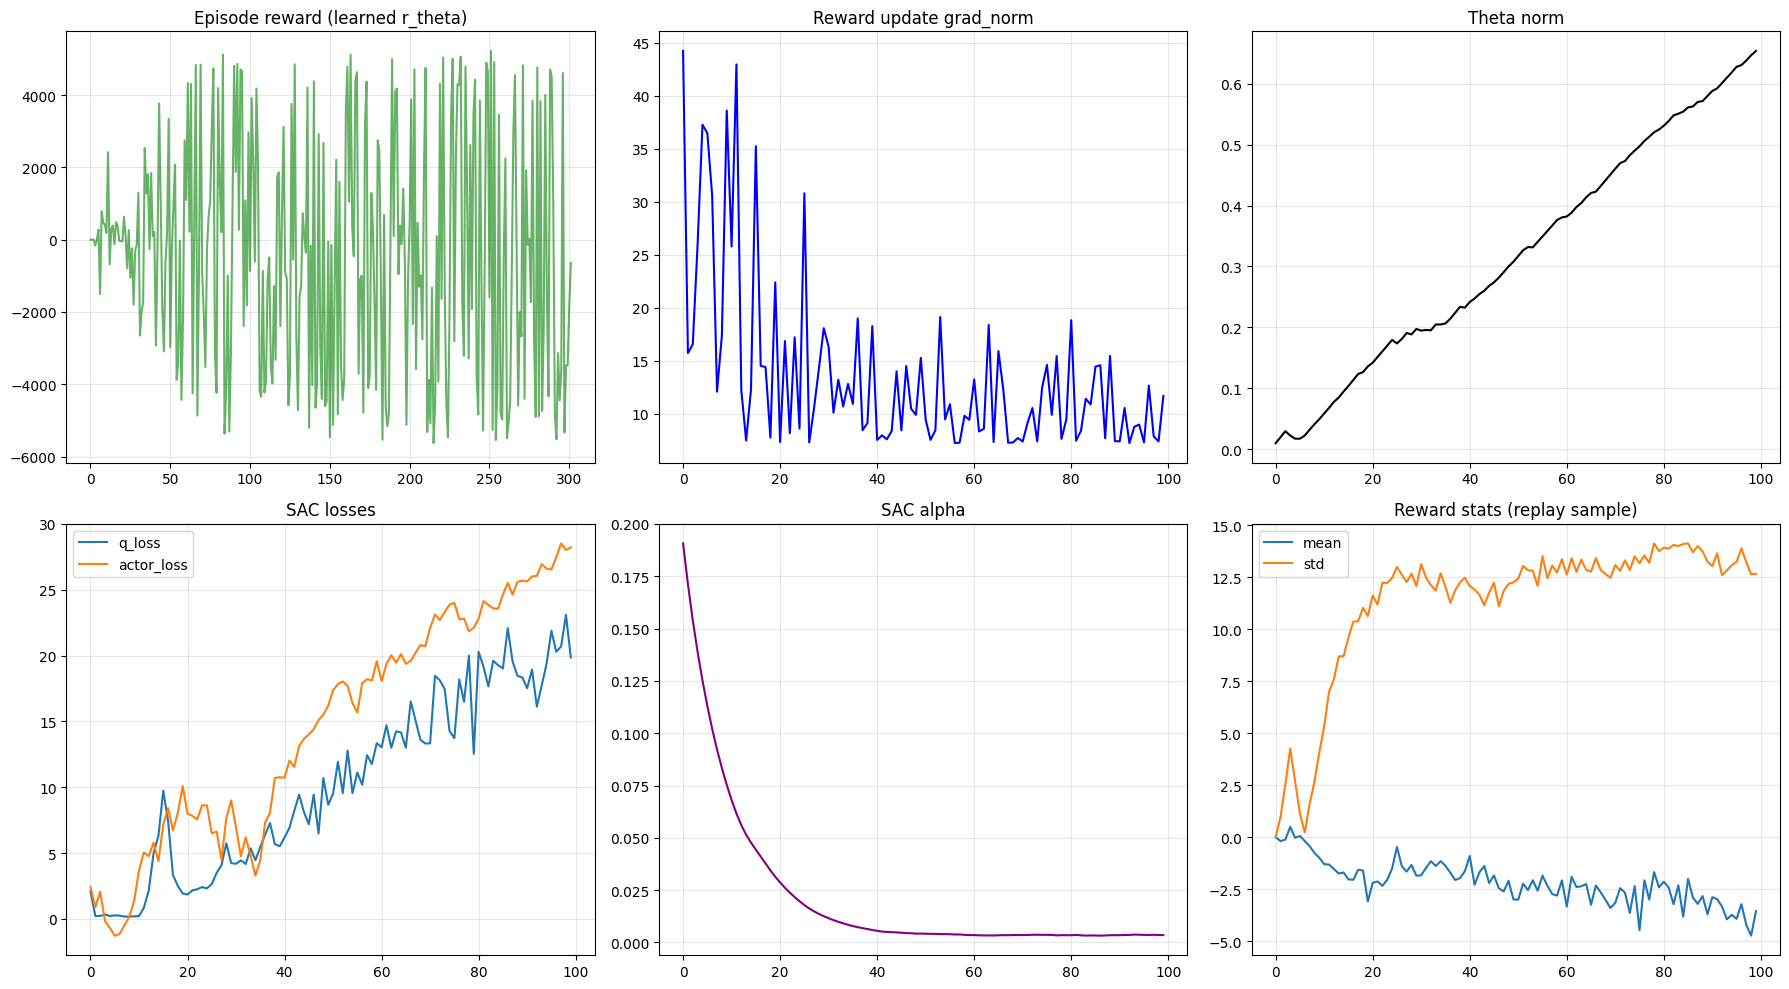


TRAINING COMPLETED


In [37]:
print("Launching IRL Variable Impedance Learning")
main()
